# Continuous Identity Trust — the actual demo

The whole idea in one line: logging someone in once and then trusting them for the
rest of the session is a bad bet. People get phished, sessions get stolen, a bot
picks up right where a real user left off — and point-in-time auth just doesn't see
any of it. You're either constantly nagging people for OTPs (and they hate you) or
you're wide open the moment after login.

So we do the other thing. Keep watching *how* someone behaves once they're in — the
way the mouse moves, the rhythm of the typing — and keep a running "how much do I
trust this session right now" number. If that number spikes, ask for another factor.
If it doesn't, the user never even knows we were watching. That's the point: friction
only shows up when something's actually wrong.

This notebook runs the entire thing top to bottom. No servers, no Redis, no
websockets — the telemetry is synthetic so you can just hit run. Everything *after*
the data generation is the real prototype though: the features, the model, the
continuous scoring, the step-up trigger, the reason codes.

Roughly what's below:
1. what the telemetry looks like (human vs bot),
2. turning raw events into behavioural features with Polars,
3. training the risk model and checking it actually generalises,
4. the money shot — catching a takeover mid-session,
5. *why* it flagged (reason codes, because "trust me" isn't an answer),
6. how much user friction the continuous approach actually saves,
7. a fleet view of lots of sessions at once,
8. the same model, shrunk down to run inside a Wasm agent in the browser.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

import cit
from cit import (
    generate_session, generate_dataset, build_feature_table,
    train_model, replay_session, FEATURE_COLS,
    train_edge_model, export_edge_model,
)

plt.rcParams.update({
    "figure.facecolor": "#11161b", "axes.facecolor": "#11161b",
    "axes.edgecolor": "#444", "text.color": "#e6e6e6",
    "axes.labelcolor": "#e6e6e6", "xtick.color": "#aaa", "ytick.color": "#aaa",
    "axes.titlecolor": "#00ffcc", "grid.color": "#222", "font.size": 11,
})
ACCENT, ALERT, HUMAN, WARN = "#00ffcc", "#ff3366", "#4aa3ff", "#ffaa00"
np.random.seed(0)
print("cit loaded — Polars", pl.__version__)

cit loaded — Polars 1.42.0


## 1 · What the agent actually sees

The client agent samples where the pointer is and how fast keys are being pressed,
a few dozen times a second. We never look at *what* someone does — no page contents,
no form data, nothing creepy. Just the physics of the movement.

A human and a bot look completely different once you plot it. A person's cursor
curves, drifts, overshoots, and jitters because a hand is a noisy analog thing. A
script draws a straight line at a constant rate and types like a metronome, because
why wouldn't it. That gap is the whole game.

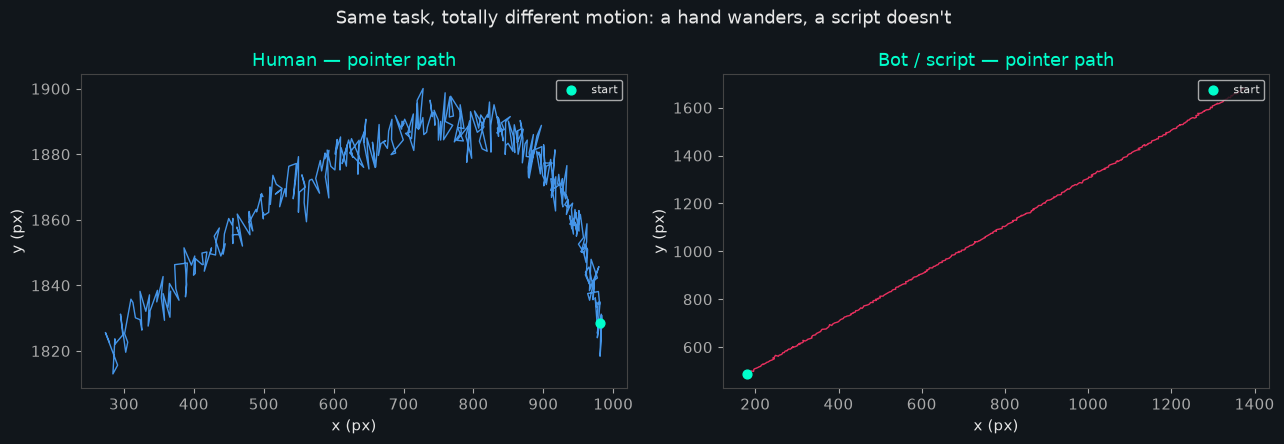

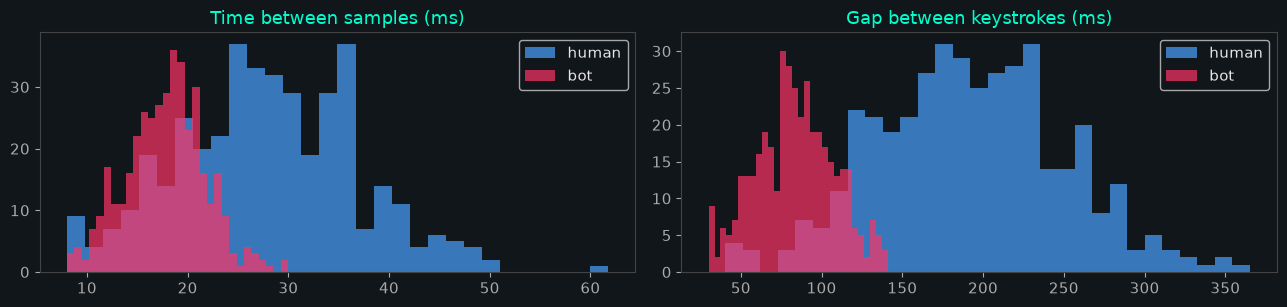

In [2]:
human = generate_session("demo_human", "human", n_events=400, seed=1)
bot   = generate_session("demo_bot",   "bot",   n_events=400, seed=2)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, sess, name, c in [(ax[0], human, "Human", HUMAN), (ax[1], bot, "Bot / script", ALERT)]:
    a.plot(sess["x"], sess["y"], c=c, lw=1.0, alpha=0.9)
    a.scatter(sess["x"][0], sess["y"][0], c=ACCENT, s=40, zorder=5, label="start")
    a.set_title(f"{name} — pointer path"); a.set_xlabel("x (px)"); a.set_ylabel("y (px)")
    a.legend(loc="upper right", fontsize=8)
fig.suptitle("Same task, totally different motion: a hand wanders, a script doesn't", color="#e6e6e6")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))
ax[0].hist(human["dt_ms"], bins=30, color=HUMAN, alpha=0.7, label="human")
ax[0].hist(bot["dt_ms"], bins=30, color=ALERT, alpha=0.7, label="bot")
ax[0].set_title("Time between samples (ms)"); ax[0].legend()
ax[1].hist(human["key_interval_ms"], bins=30, color=HUMAN, alpha=0.7, label="human")
ax[1].hist(bot["key_interval_ms"], bins=30, color=ALERT, alpha=0.7, label="bot")
ax[1].set_title("Gap between keystrokes (ms)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 2 · Squeezing features out of the stream (Polars)

Raw x/y points aren't much use to a model directly. So we chop each session into
short overlapping windows and boil every window down to seven numbers that describe
*how* the motion happened. This is the bit the pitch calls real-time micro-batch
aggregation — in production Polars does it on the live stream; here it does it on the
whole dataset at once, same code.

The seven features, in plain English:
- **speed_mean / speed_std** — how fast the pointer moves, and how much that varies.
- **accel_std** — jerkiness. Human hands are constantly making tiny corrections.
- **path_efficiency** — straight-line distance ÷ actual path length. A bot's is basically 1.
- **angle_std** — how much the direction changes. Straight-line bots barely turn.
- **dt_std** — jitter in the sampling clock. Scripts are metronomic.
- **key_interval_std** — variation in typing rhythm. Same story.

None of these are black boxes, which matters later when we have to explain a decision.

In [3]:
dataset = generate_dataset(n_human=120, n_bot=120, n_events=400, seed=7)
feat = build_feature_table(dataset, window=50, stride=25)
print(f"{dataset.height:,} raw events  ->  {feat.height:,} feature windows "
      f"across {feat['session_id'].n_unique()} sessions")
feat.select(FEATURE_COLS + ["label"]).head(5)

96,000 raw events  ->  3,600 feature windows across 240 sessions


speed_mean,speed_std,accel_std,path_efficiency,angle_std,dt_std,key_interval_std,label
f64,f64,f64,f64,f64,f64,f64,i64
0.317076,0.237935,0.325307,0.339105,2.059667,8.545516,59.206692,0
0.280948,0.171831,0.259216,0.348493,2.060501,7.123254,57.771566,0
0.263659,0.186534,0.287808,0.39492,1.954736,8.283951,45.034071,0
0.254481,0.186931,0.290501,0.34768,1.970346,9.650531,40.942021,0
0.245846,0.162212,0.252757,0.283989,2.040484,9.457586,54.902485,0


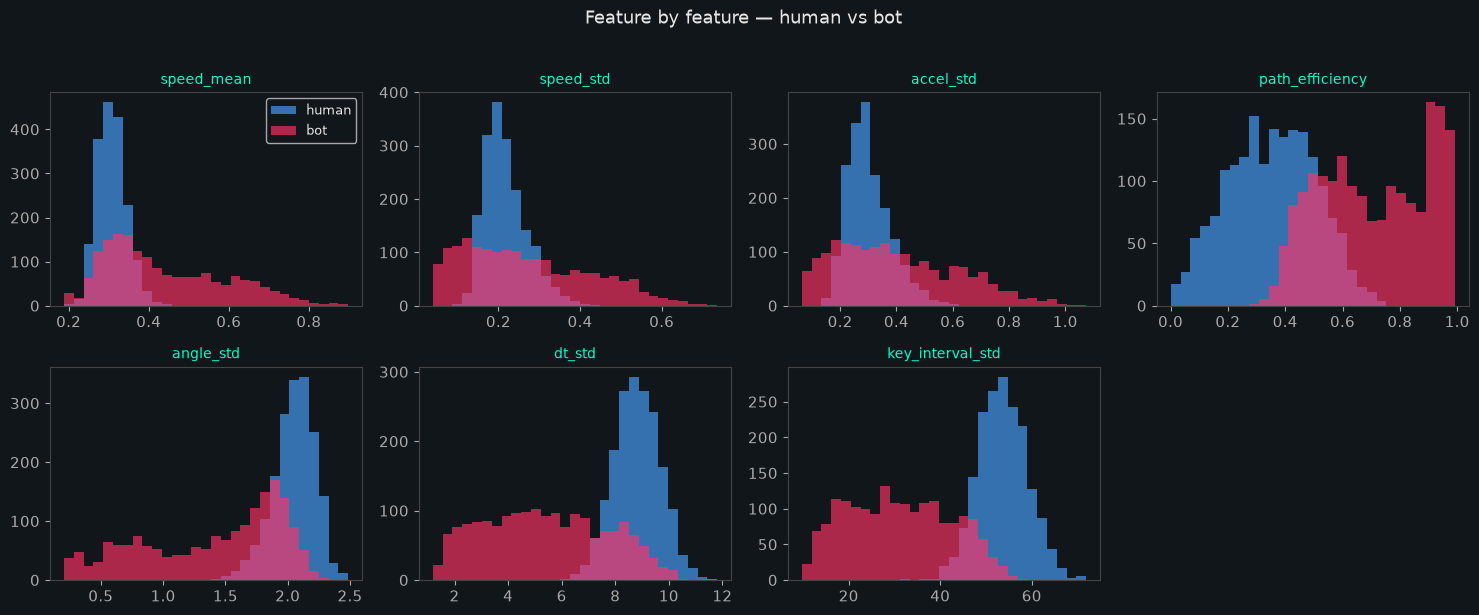

In [4]:
# quick look at how well each feature separates the two groups on its own
hum = feat.filter(pl.col("label") == 0)
bt  = feat.filter(pl.col("label") == 1)
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.ravel(), FEATURE_COLS):
    lo = float(min(hum[col].min(), bt[col].min()))
    hi = float(max(hum[col].max(), bt[col].max()))
    bins = np.linspace(lo, hi, 30)
    ax.hist(hum[col], bins=bins, color=HUMAN, alpha=0.65, label="human")
    ax.hist(bt[col],  bins=bins, color=ALERT, alpha=0.65, label="bot")
    ax.set_title(col, fontsize=10)
axes.ravel()[-1].axis("off")
axes.ravel()[0].legend(fontsize=9)
fig.suptitle("Feature by feature — human vs bot", color="#e6e6e6", y=1.02)
plt.tight_layout(); plt.show()

## 3 · Training the model (and not fooling ourselves)

A gradient-boosted classifier learns the boundary between human and bot windows.
One thing that's easy to get wrong here: if you split windows randomly, windows from
the *same* session end up in both train and test, and the model looks amazing for the
wrong reason. So we split **by session** instead — a session is either fully in train
or fully in test, never both.

Heads up on the numbers: on this synthetic data the features separate really cleanly,
so accuracy sits near the ceiling. That's a property of clean generated data, not a
brag. The genuinely hard problem in production isn't drawing this boundary — it's
drift and attackers who actively try to look human. Which is exactly why the engine
doesn't trust any single window's score and leans on a smoothed running state instead
(that's the next section).

In [5]:
sids = feat["session_id"].unique().to_list()
rng = np.random.default_rng(0); rng.shuffle(sids)
cut = int(len(sids) * 0.3)
test_ids, train_ids = set(sids[:cut]), set(sids[cut:])
train = feat.filter(pl.col("session_id").is_in(list(train_ids)))
test  = feat.filter(pl.col("session_id").is_in(list(test_ids)))

model = train_model(train)
proba = model.score_windows(test)
y_true = test["label"].to_numpy()
auc = roc_auc_score(y_true, proba)
print(f"Held-out sessions: {len(test_ids)} | windows: {test.height}")
print(f"Window-level ROC-AUC: {auc:.4f}\n")
print(classification_report(y_true, (proba >= 0.5).astype(int),
                            target_names=["human", "bot"]))

Held-out sessions: 72 | windows: 1080
Window-level ROC-AUC: 0.9969

              precision    recall  f1-score   support

       human       1.00      1.00      1.00       630
         bot       1.00      1.00      1.00       450

    accuracy                           1.00      1080
   macro avg       1.00      1.00      1.00      1080
weighted avg       1.00      1.00      1.00      1080



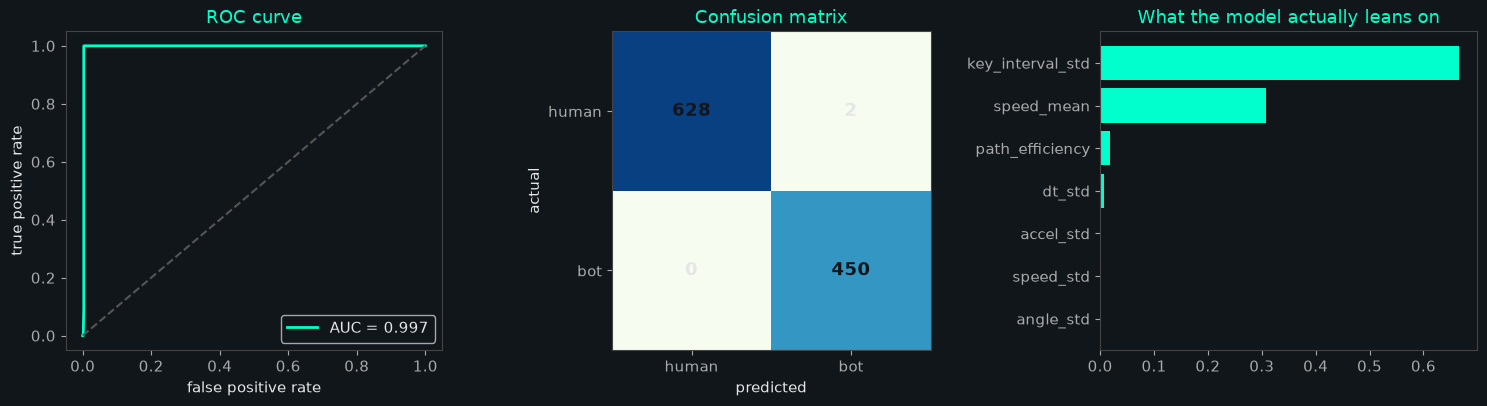

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
fpr, tpr, _ = roc_curve(y_true, proba)
ax[0].plot(fpr, tpr, c=ACCENT, lw=2, label=f"AUC = {auc:.3f}")
ax[0].plot([0, 1], [0, 1], "--", c="#555")
ax[0].set_title("ROC curve"); ax[0].set_xlabel("false positive rate")
ax[0].set_ylabel("true positive rate"); ax[0].legend(loc="lower right")
cm = confusion_matrix(y_true, (proba >= 0.5).astype(int))
ax[1].imshow(cm, cmap="GnBu")
ax[1].set_xticks([0, 1], ["human", "bot"]); ax[1].set_yticks([0, 1], ["human", "bot"])
ax[1].set_xlabel("predicted"); ax[1].set_ylabel("actual"); ax[1].set_title("Confusion matrix")
for (i, j), v in np.ndenumerate(cm):
    ax[1].text(j, i, str(v), ha="center", va="center",
               color="#11161b" if v > cm.max()/2 else "#e6e6e6", fontsize=13, weight="bold")
imp = model.clf.feature_importances_
order = np.argsort(imp)
ax[2].barh(np.array(FEATURE_COLS)[order], imp[order], color=ACCENT)
ax[2].set_title("What the model actually leans on")
plt.tight_layout(); plt.show()

## 4 · The money shot — catching a takeover mid-session

Here's the scenario static auth can't touch. A session logs in as a legit human,
sails through the front door... and halfway through, someone else takes the wheel — a
stolen session, a remote-access tool, a replay script. The login was real. Everything
after it isn't.

We stream the session through the engine one window at a time. Each window gives an
instantaneous risk; we run that through an exponential moving average to get the
smoothed **risk state** (the thing that'd live in Redis). The smoothing is deliberate
— one weird window shouldn't fire an alarm, a *sustained* shift should. The second
that smoothed state crosses the line, step-up fires. No human in the loop, no waiting.

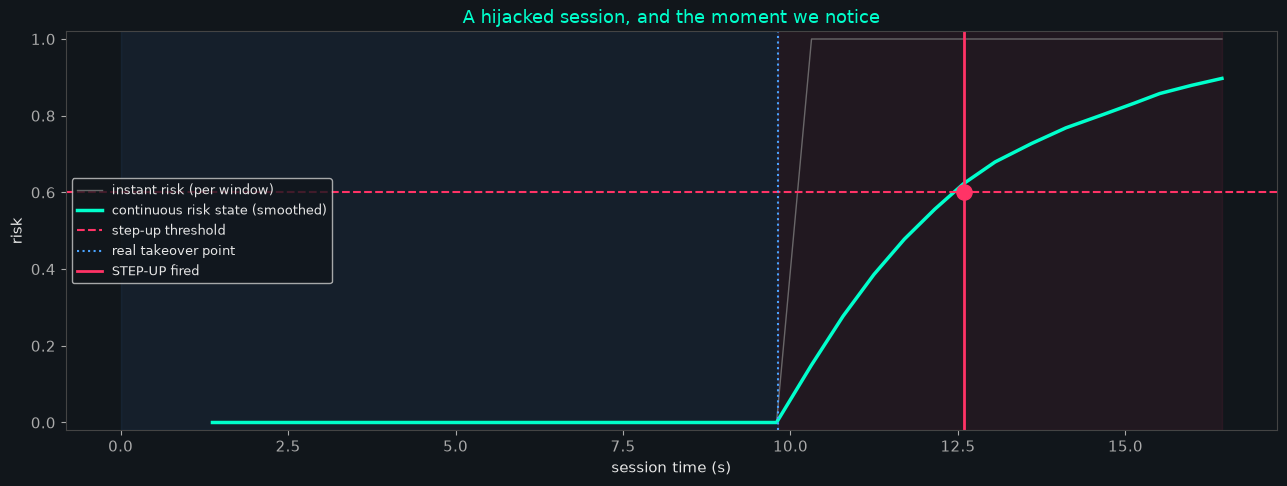

takeover happened at t =    9.8s
step-up fired at     t =   12.6s
so we caught it       2.8s after the session went bad


In [7]:
ato = generate_session("ato_demo", "account_takeover", n_events=700,
                       takeover_at=0.5, seed=42)
mon = replay_session(model, ato, window=50, stride=25,
                     ema_alpha=0.15, step_up_threshold=0.6)
h = mon.to_frame()
takeover_t = float(ato["t_ms"][int(700 * 0.5)])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(h["t_end_ms"]/1000, h["instant_risk"], c="#888", lw=1, alpha=0.7,
        label="instant risk (per window)")
ax.plot(h["t_end_ms"]/1000, h["risk_state"], c=ACCENT, lw=2.5,
        label="continuous risk state (smoothed)")
ax.axhline(0.6, ls="--", c=ALERT, lw=1.5, label="step-up threshold")
ax.axvspan(0, takeover_t/1000, color=HUMAN, alpha=0.07)
ax.axvspan(takeover_t/1000, h["t_end_ms"].max()/1000, color=ALERT, alpha=0.07)
ax.axvline(takeover_t/1000, c=HUMAN, ls=":", lw=1.5, label="real takeover point")
if mon.step_up_t_ms:
    ax.axvline(mon.step_up_t_ms/1000, c=ALERT, lw=2, label="STEP-UP fired")
    ax.scatter([mon.step_up_t_ms/1000], [0.6], c=ALERT, s=120, zorder=6)
ax.set_xlabel("session time (s)"); ax.set_ylabel("risk")
ax.set_ylim(-0.02, 1.02); ax.set_title("A hijacked session, and the moment we notice")
ax.legend(loc="center left", fontsize=9)
plt.tight_layout(); plt.show()

if mon.step_up_t_ms:
    lag = (mon.step_up_t_ms - takeover_t) / 1000
    print(f"takeover happened at t = {takeover_t/1000:6.1f}s")
    print(f"step-up fired at     t = {mon.step_up_t_ms/1000:6.1f}s")
    print(f"so we caught it       {lag:.1f}s after the session went bad")

## 5 · "Why did it flag?" — reason codes

A risk score on its own is annoying. If a fraud analyst (or the user) asks "okay, why
did you challenge me", "the number went up" is not a great answer. So when the engine
steps up, it also records *which* behaviours drifted, and by how much, measured
against that user's human baseline (in standard deviations).

Nothing fancy — for each feature we check how many sigmas it sits away from normal,
signed so that "more bot-like" is positive, and keep the biggest offenders. It turns
an opaque score into something you could actually put in an alert or an audit log.

step-up reasons for the takeover above:

  • pointer speed              11.0 sigma from the human baseline
  • speed consistency           5.2 sigma from the human baseline
  • acceleration smoothness     4.5 sigma from the human baseline


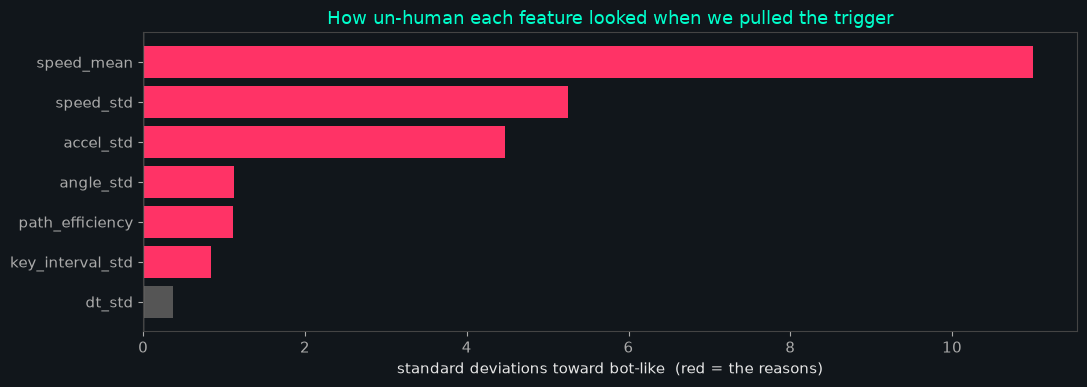

In [8]:
print("step-up reasons for the takeover above:\n")
for r in mon.step_up_reasons:
    print(f"  • {r['what']:<26} {r['sigma']:4.1f} sigma from the human baseline")

# same thing as a picture: how far each feature drifted at the flagging window
from cit.features import features_from_window
# grab the window that tipped it over
idx = int(np.argmin(np.abs(h["t_end_ms"].to_numpy() - mon.step_up_t_ms)))
start = idx * 25
fw = features_from_window(ato.slice(start, 50))
x = np.array([fw[c] for c in FEATURE_COLS])
z = (x - model.human_mean) / model.human_std * model.bot_direction
order = np.argsort(z)
colors = [ALERT if v > 0.5 else "#555" for v in z[order]]
fig, ax = plt.subplots(figsize=(11, 4))
ax.barh(np.array(FEATURE_COLS)[order], z[order], color=colors)
ax.axvline(0, c="#888", lw=1)
ax.set_xlabel("standard deviations toward bot-like  (red = the reasons)")
ax.set_title("How un-human each feature looked when we pulled the trigger")
plt.tight_layout(); plt.show()

## 6 · Does the continuous approach actually save friction?

Easy to claim, so let's check it. The lazy version of this system just challenges the
user any time a single window looks suspicious. Trouble is, real people occasionally do
bot-ish things for a second — dragging a scrollbar in a dead-straight line, flinging
the cursor across the screen. For that one window the geometry looks exactly like a
script, and a per-window trigger will happily interrupt them. That's the friction
we're trying to avoid.

To make this honest we need humans who *aren't* perfectly clean, so below we generate
genuine human sessions that include a couple of those straight-line drags. Then we
compare two policies: challenge on any single scary window vs challenge only when the
smoothed state crosses the line. Same 700-event takeovers as before for the catch
rate.

genuine (but slightly draggy) humans that got challenged — false alarms:
   per-window trigger : 80/80  (100%)
   continuous state   : 2/80  (2%)

takeovers caught (out of 20):
   per-window trigger : 20   continuous state : 20


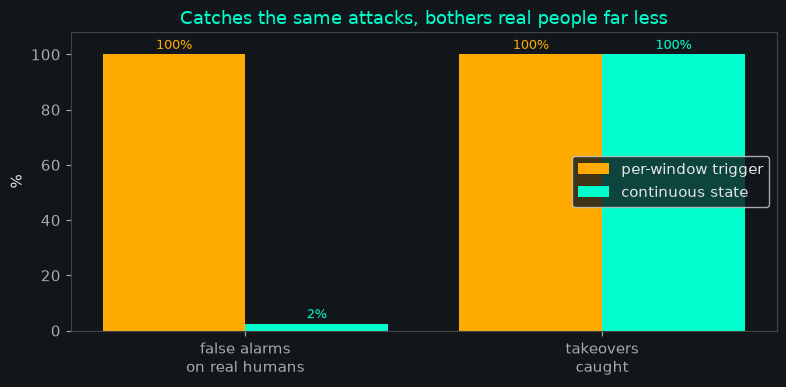

In [9]:
def human_with_drags(seed, n_drags=2, drag_len=22):
    # a genuine human, but a couple of times they drag the cursor in a straight
    # line (scrollbar / slider). Human timing, straight geometry — the kind of
    # blip that fools a naive per-window check.
    rng = np.random.default_rng(seed)
    s = generate_session("x", "human", 700, seed=seed)
    x = s["x"].to_numpy().copy(); y = s["y"].to_numpy().copy()
    for st in sorted(rng.choice(range(50, 650), n_drags, replace=False)):
        ang = rng.uniform(0, 2*np.pi); L = rng.uniform(400, 900)
        t = np.linspace(0, 1, drag_len)
        x[st:st+drag_len] = x[st] + np.cos(ang)*L*t + rng.normal(0, 1.5, drag_len)
        y[st:st+drag_len] = y[st] + np.sin(ang)*L*t + rng.normal(0, 1.5, drag_len)
    return s.with_columns(pl.Series("x", x), pl.Series("y", y))

N_HUM, N_ATO = 80, 20
naive_fp = cont_fp = naive_tp = cont_tp = 0
for i in range(N_HUM):
    m = replay_session(model, human_with_drags(4000+i), ema_alpha=0.15, step_up_threshold=0.6)
    naive_fp += bool((m.to_frame()["instant_risk"] >= 0.5).any())
    cont_fp += m.stepped_up
for i in range(N_ATO):
    ato_s = generate_session(f"a{i}", "account_takeover", 700, takeover_at=0.5, seed=2000+i)
    m = replay_session(model, ato_s, ema_alpha=0.15, step_up_threshold=0.6)
    naive_tp += bool((m.to_frame()["instant_risk"] >= 0.5).any())
    cont_tp += m.stepped_up

print("genuine (but slightly draggy) humans that got challenged — false alarms:")
print(f"   per-window trigger : {naive_fp}/{N_HUM}  ({100*naive_fp/N_HUM:.0f}%)")
print(f"   continuous state   : {cont_fp}/{N_HUM}  ({100*cont_fp/N_HUM:.0f}%)")
print(f"\ntakeovers caught (out of {N_ATO}):")
print(f"   per-window trigger : {naive_tp}   continuous state : {cont_tp}")

fig, ax = plt.subplots(figsize=(8, 4))
labels = ["false alarms\non real humans", "takeovers\ncaught"]
xs = np.arange(2)
ax.bar(xs-0.2, [100*naive_fp/N_HUM, 100*naive_tp/N_ATO], width=0.4, color=WARN, label="per-window trigger")
ax.bar(xs+0.2, [100*cont_fp/N_HUM, 100*cont_tp/N_ATO], width=0.4, color=ACCENT, label="continuous state")
ax.set_xticks(xs, labels); ax.set_ylabel("%"); ax.set_ylim(0, 108)
for i, v in enumerate([100*naive_fp/N_HUM, 100*naive_tp/N_ATO]):
    ax.text(i-0.2, v+2, f"{v:.0f}%", ha="center", color=WARN, fontsize=9)
for i, v in enumerate([100*cont_fp/N_HUM, 100*cont_tp/N_ATO]):
    ax.text(i+0.2, v+2, f"{v:.0f}%", ha="center", color=ACCENT, fontsize=9)
ax.set_title("Catches the same attacks, bothers real people far less")
ax.legend(loc="center right")
plt.tight_layout(); plt.show()

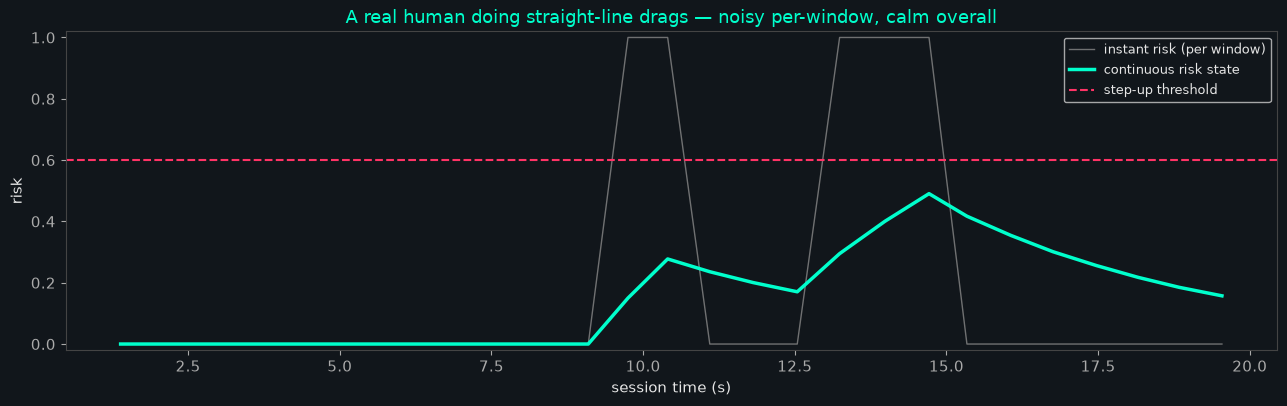

stepped up? False — exactly what you want: no, this is just a person.


In [10]:
# one draggy human up close: the instant score keeps spiking over the line,
# the smoothed state shrugs it off and never triggers.
demo = human_with_drags(4007)
m = replay_session(model, demo, ema_alpha=0.15, step_up_threshold=0.6)
hh = m.to_frame()
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(hh["t_end_ms"]/1000, hh["instant_risk"], c="#888", lw=1, alpha=0.8, label="instant risk (per window)")
ax.plot(hh["t_end_ms"]/1000, hh["risk_state"], c=ACCENT, lw=2.5, label="continuous risk state")
ax.axhline(0.6, ls="--", c=ALERT, lw=1.5, label="step-up threshold")
ax.set_ylim(-0.02, 1.02); ax.set_xlabel("session time (s)"); ax.set_ylabel("risk")
ax.set_title("A real human doing straight-line drags — noisy per-window, calm overall")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()
print("stepped up?", m.stepped_up, "— exactly what you want: no, this is just a person.")

## 7 · The fleet view

In production Redis holds one live risk number per active session — thousands of them.
Here's a smaller version: a mix of real humans, outright bots, and takeovers, all
streamed through the engine at once, their risk states drawn on top of each other. The
honest sessions stay down near zero; the bad ones climb and trip the line. The dots
mark where step-up fired.

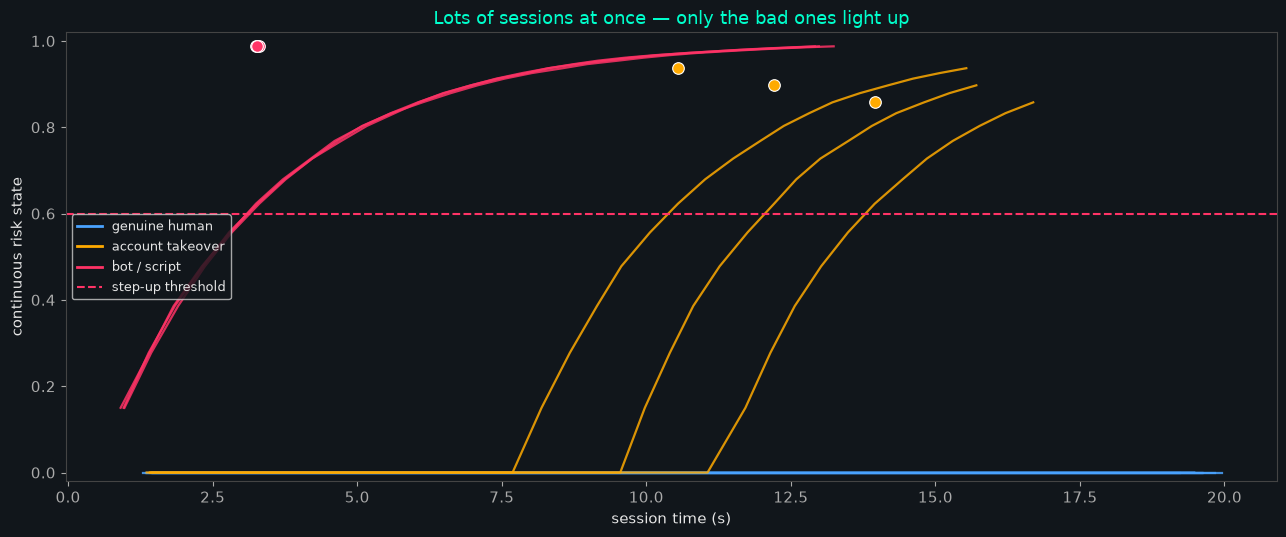

6 of 12 sessions escalated; all 6 genuine humans were left alone.


In [11]:
scenarios = (
    [("human", f"user-{i}", None) for i in range(6)] +
    [("bot", f"bot-{i}", None) for i in range(3)] +
    [("account_takeover", f"ato-{i}", 0.4 + 0.1*i) for i in range(3)]
)
fig, ax = plt.subplots(figsize=(13, 5.5))
flagged = 0
for kind, name, ta in scenarios:
    kw = dict(takeover_at=ta) if ta else {}
    s = generate_session(name, kind, n_events=700, seed=abs(hash(name)) % 9999, **kw)
    m = replay_session(model, s, ema_alpha=0.15, step_up_threshold=0.6)
    hh = m.to_frame()
    color = {"human": HUMAN, "bot": ALERT, "account_takeover": WARN}[kind]
    ax.plot(hh["t_end_ms"]/1000, hh["risk_state"], c=color, lw=1.6, alpha=0.85)
    if m.stepped_up:
        flagged += 1
        ax.scatter([m.step_up_t_ms/1000], [m.risk], c=color, s=70, zorder=5,
                   edgecolors="white", linewidths=0.8)
ax.axhline(0.6, ls="--", c=ALERT, lw=1.5)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color=HUMAN, lw=2, label="genuine human"),
    Line2D([0],[0], color=WARN, lw=2, label="account takeover"),
    Line2D([0],[0], color=ALERT, lw=2, label="bot / script"),
    Line2D([0],[0], color=ALERT, ls="--", label="step-up threshold"),
], loc="center left", fontsize=9)
ax.set_xlabel("session time (s)"); ax.set_ylabel("continuous risk state")
ax.set_ylim(-0.02, 1.02); ax.set_title("Lots of sessions at once — only the bad ones light up")
plt.tight_layout(); plt.show()
print(f"{flagged} of {len(scenarios)} sessions escalated; "
      f"all {sum(1 for k,_,_ in scenarios if k=='human')} genuine humans were left alone.")

## 8 · Shrinking the model down to the edge (Wasm)

The gradient-boosted model is the real brain, but you don't want to ship a tree
ensemble into a tiny client agent. So we also fit a plain logistic regression on the
exact same features — it's just a scale, a dot product, and a sigmoid, which is small
enough to run *inside the browser* with no server round-trip. First-pass risk right on
the client, before the stream even leaves the machine.

The cell below exports that little model to `web/model.json`. There's also a Rust
crate in `agent/` that compiles to a ~2 kB Wasm blob and computes these same seven
features on live mouse/keyboard input (it matches `features.py` to the decimal — I
checked). Open **`web/live.html`** in a browser, wiggle the mouse, type a bit, then
hit "simulate takeover" and watch the risk climb for real.

In [12]:
scaler, clf = train_edge_model(feat)
payload = export_edge_model(scaler, clf, "web/model.json")
edge_auc = roc_auc_score(
    feat["label"].to_numpy(),
    clf.predict_proba(scaler.transform(feat.select(FEATURE_COLS).to_numpy()))[:, 1],
)
print("edge model written to web/model.json")
print(f"it's {len(payload['coef'])} weights + a bias — that's the entire 'model'.")
print(f"in-sample AUC: {edge_auc:.4f}  (a hair behind the big model, tiny enough to ship)")
print("\nto play with it live:  cd web && python -m http.server  ->  open localhost:8000/live.html")

edge model written to web/model.json
it's 7 weights + a bias — that's the entire 'model'.
in-sample AUC: 1.0000  (a hair behind the big model, tiny enough to ship)

to play with it live:  cd web && python -m http.server  ->  open localhost:8000/live.html


## So what's real here, and what's next

The decision core is real: the feature engineering, the model, the continuous risk
state, the step-up trigger, the reason codes, and a working Wasm agent that runs the
same feature maths in a browser. That's the hard part and it's done.

Turning it into a product is mostly swapping the data source and scaling the runtime:

| Piece | This prototype | Production (per the pitch) |
|-------|----------------|----------------------------|
| Telemetry | synthetic generator | the Wasm agent in `agent/`, streaming for real |
| Ingestion | in-process Polars | async Python + websockets + Polars |
| Inference | scikit-learn GBM | PyTorch / XGBoost, Numba-compiled features |
| Session state | a `SessionMonitor` object | Redis, one risk score per live session |
| The action | a `stepped_up` flag | an API call that forces step-up auth |

The one-liner to take away: trust isn't a gate you pass once, it's a number you keep
watching — and you can defend it in real time without making honest users suffer.